# CIFAR-100 EDA Analysis using PyTorch + torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import resnet18
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Data transforms and loaders

In [4]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_set = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform
)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 169M/169M [00:03<00:00, 43.5MB/s]


In [5]:
classes_100 = train_set.classes
print("Number of classes:", len(classes_100))
print("Train size:", len(train_set))
print("Test size:", len(test_set))

Number of classes: 100
Train size: 50000
Test size: 10000


In [6]:
# --- Basic label distribution ---
train_labels = [label for _, label in train_set]
test_labels = [label for _, label in test_set]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print("Train label counts:", train_counts)
print("Test label counts:", test_counts)

Train label counts: Counter({19: 500, 29: 500, 0: 500, 11: 500, 1: 500, 86: 500, 90: 500, 28: 500, 23: 500, 31: 500, 39: 500, 96: 500, 82: 500, 17: 500, 71: 500, 8: 500, 97: 500, 80: 500, 74: 500, 59: 500, 70: 500, 87: 500, 84: 500, 64: 500, 52: 500, 42: 500, 47: 500, 65: 500, 21: 500, 22: 500, 81: 500, 24: 500, 78: 500, 45: 500, 49: 500, 56: 500, 76: 500, 89: 500, 73: 500, 14: 500, 9: 500, 6: 500, 20: 500, 98: 500, 36: 500, 55: 500, 72: 500, 43: 500, 51: 500, 35: 500, 83: 500, 33: 500, 27: 500, 53: 500, 92: 500, 50: 500, 15: 500, 18: 500, 46: 500, 75: 500, 38: 500, 66: 500, 77: 500, 69: 500, 95: 500, 99: 500, 93: 500, 4: 500, 61: 500, 94: 500, 68: 500, 34: 500, 32: 500, 88: 500, 67: 500, 30: 500, 62: 500, 63: 500, 40: 500, 26: 500, 48: 500, 79: 500, 85: 500, 54: 500, 44: 500, 7: 500, 12: 500, 2: 500, 41: 500, 37: 500, 13: 500, 25: 500, 10: 500, 57: 500, 5: 500, 60: 500, 91: 500, 3: 500, 58: 500, 16: 500})
Test label counts: Counter({49: 100, 33: 100, 72: 100, 51: 100, 71: 100, 92: 100

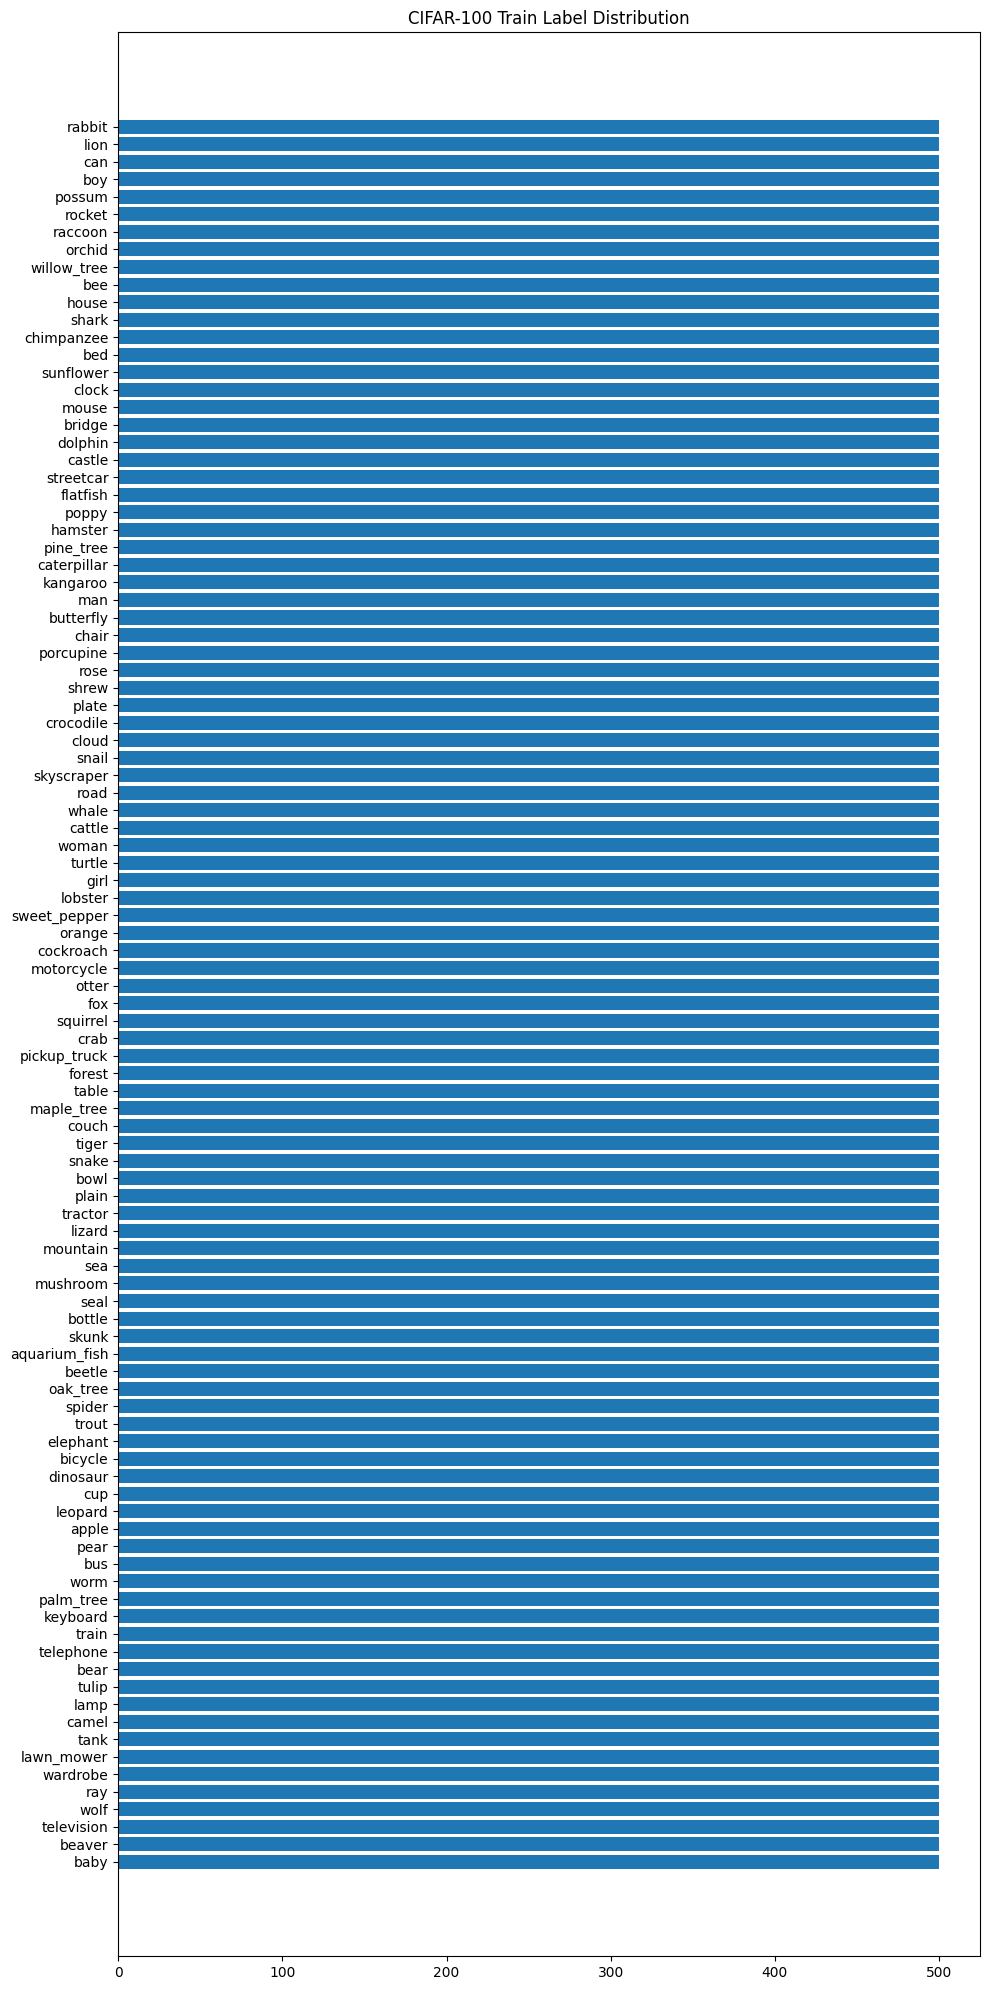

In [9]:
def plot_label_distribution_hbar(counts, title):
    labels = list(counts.keys())
    values = [counts[k] for k in labels]

    plt.figure(figsize=(10, 20))
    plt.barh(labels, values)
    plt.yticks(labels, classes_100)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_label_distribution_hbar(train_counts, "CIFAR-100 Train Label Distribution")

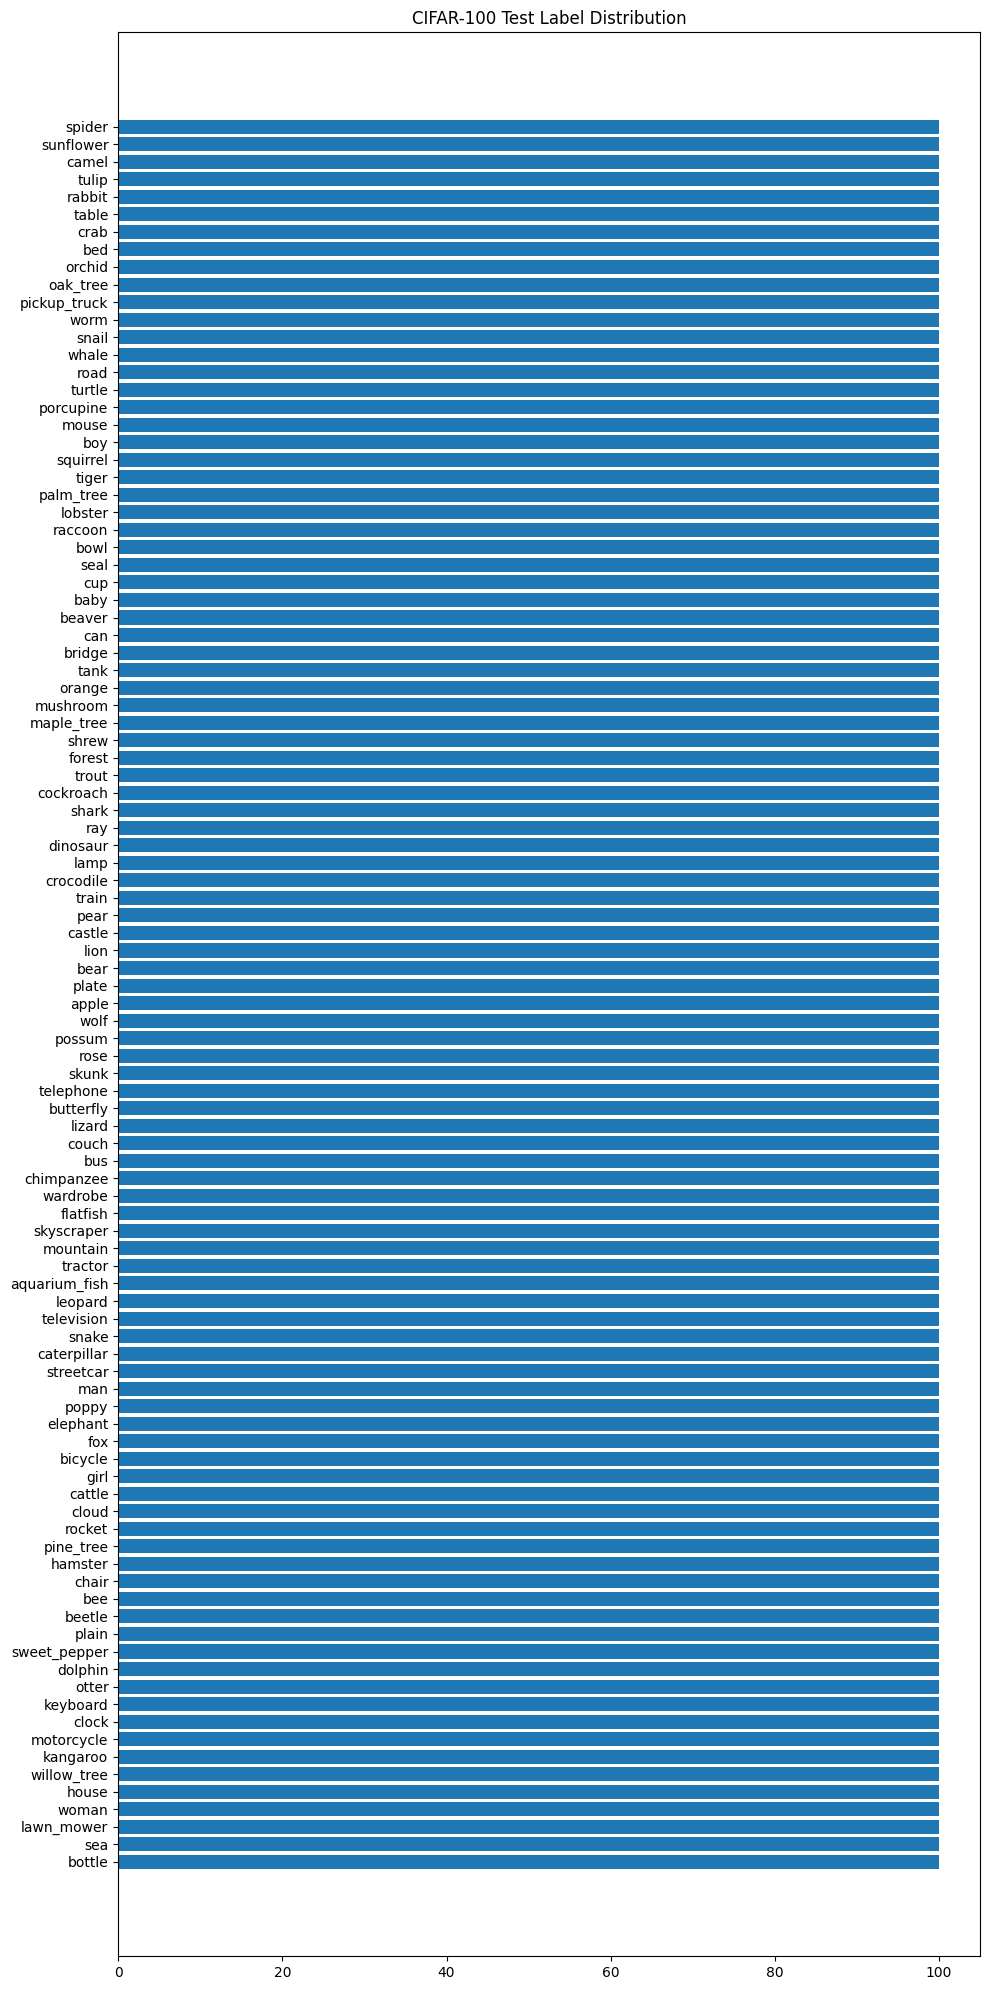

In [10]:
plot_label_distribution_hbar(test_counts, "CIFAR-100 Test Label Distribution")

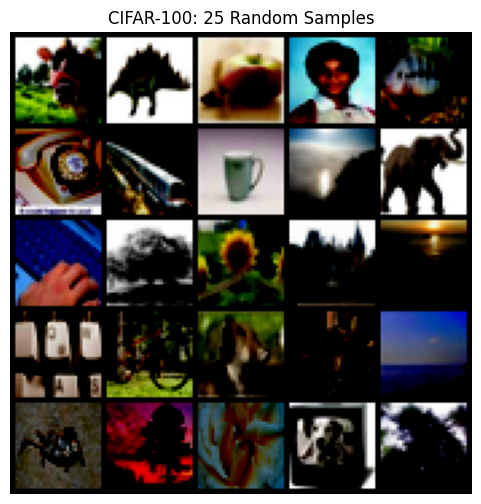

Labels for shown images: ['cattle', 'dinosaur', 'apple', 'boy', 'aquarium_fish', 'telephone', 'train', 'cup', 'cloud', 'elephant', 'keyboard', 'willow_tree', 'sunflower', 'castle', 'sea', 'keyboard', 'bicycle', 'wolf', 'squirrel', 'sea', 'shrew', 'pine_tree', 'rose', 'television', 'pine_tree']


In [11]:
# Sample grid of images
def imshow(img, title=None):
    img = img / 2 + 0.5 if img.max() > 1 else img
    npimg = img.numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()
indices = list(range(25))
images_100 = torch.stack([train_set[i][0] for i in indices])
labels_100 = [classes_100[train_set[i][1]] for i in indices]
imshow(torchvision.utils.make_grid(images_100, nrow=5), title="CIFAR-100: 25 Random Samples")
print("Labels for shown images:", labels_100)

In [12]:
# Image statistics
all_imgs_100 = torch.stack([img for img, _ in torch.utils.data.Subset(train_set, range(5000))])
mean_100 = all_imgs_100.mean(dim=[0, 2, 3])
std_100 = all_imgs_100.std(dim=[0, 2, 3])
print("CIFAR-100 train subset mean:", mean_100)
print("CIFAR-100 train subset std:", std_100)

CIFAR-100 train subset mean: tensor([ 0.0114, -0.0285, -0.1182])
CIFAR-100 train subset std: tensor([0.5356, 0.5124, 0.5518])


# 2. Pretrained model as feature extractor

In [13]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()  # remove final classification layer
resnet = resnet.to(device)
resnet.eval()

@torch.no_grad()
def extract_features(dataloader):
    features_list = []
    labels_list = []
    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        feats = resnet(imgs)              # [batch, 512]
        feats = feats.cpu().numpy()
        features_list.append(feats)
        labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

print("Extracting train features...")
X_train, y_train = extract_features(train_loader)
print("Extracting test features...")
X_test, y_test = extract_features(test_loader)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Extracting train features...
Extracting test features...


In [14]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 512)
y_train shape: (50000,)
X_test shape: (10000, 512)
y_test shape: (10000,)


In [15]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train label distribution:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("Test label distribution:", dict(zip(unique, counts)))

Train label distribution: {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(500), np.int64(3): np.int64(500), np.int64(4): np.int64(500), np.int64(5): np.int64(500), np.int64(6): np.int64(500), np.int64(7): np.int64(500), np.int64(8): np.int64(500), np.int64(9): np.int64(500), np.int64(10): np.int64(500), np.int64(11): np.int64(500), np.int64(12): np.int64(500), np.int64(13): np.int64(500), np.int64(14): np.int64(500), np.int64(15): np.int64(500), np.int64(16): np.int64(500), np.int64(17): np.int64(500), np.int64(18): np.int64(500), np.int64(19): np.int64(500), np.int64(20): np.int64(500), np.int64(21): np.int64(500), np.int64(22): np.int64(500), np.int64(23): np.int64(500), np.int64(24): np.int64(500), np.int64(25): np.int64(500), np.int64(26): np.int64(500), np.int64(27): np.int64(500), np.int64(28): np.int64(500), np.int64(29): np.int64(500), np.int64(30): np.int64(500), np.int64(31): np.int64(500), np.int64(32): np.int64(500), np.int64(33): np.int64(500

In [16]:
def feature_Variance_Plot(X, title):
  plt.figure(figsize=(12,4))
  plt.plot(np.var(X, axis=0))
  plt.title(title)
  plt.xlabel("Feature Index")
  plt.ylabel("Variance")
  plt.show()

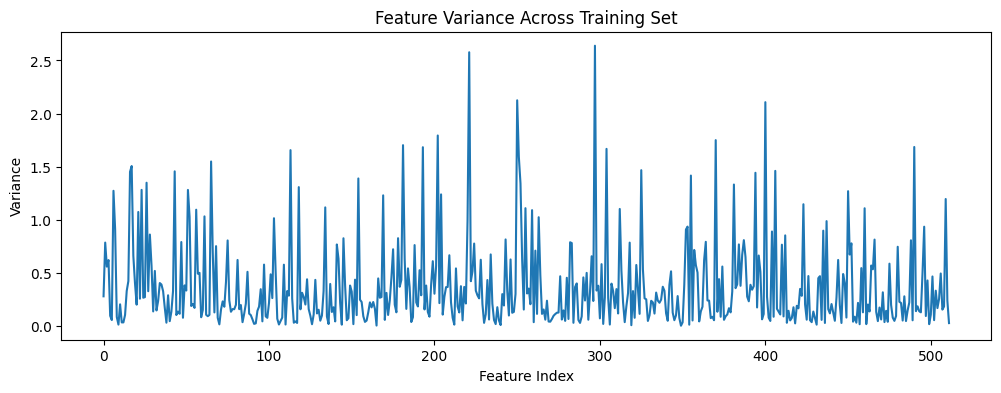

In [17]:
feature_Variance_Plot(X_train, "Feature Variance Across Training Set")

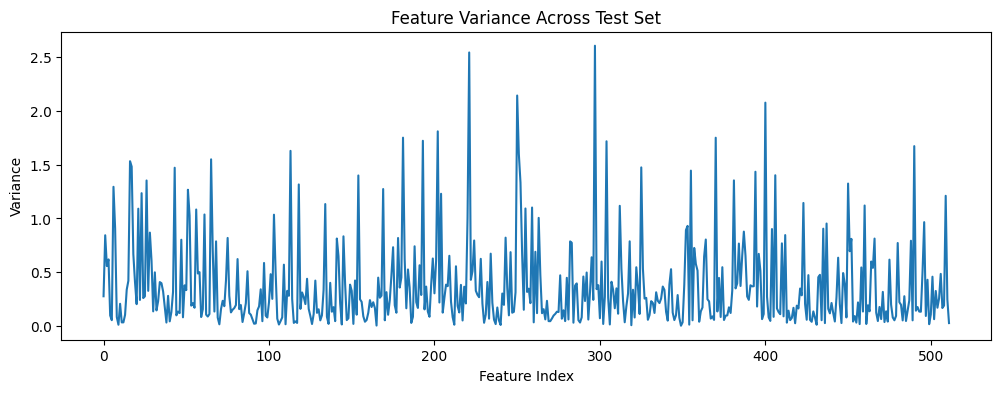

In [18]:
feature_Variance_Plot(X_test,"Feature Variance Across Test Set")

In [19]:
def PCA_plot(X, title):
  pca = PCA(n_components=2)
  X_train_pca = pca.fit_transform(X)

  plt.figure(figsize=(8,6))
  plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, s=5, cmap='tab10')
  plt.title(title)
  plt.show()

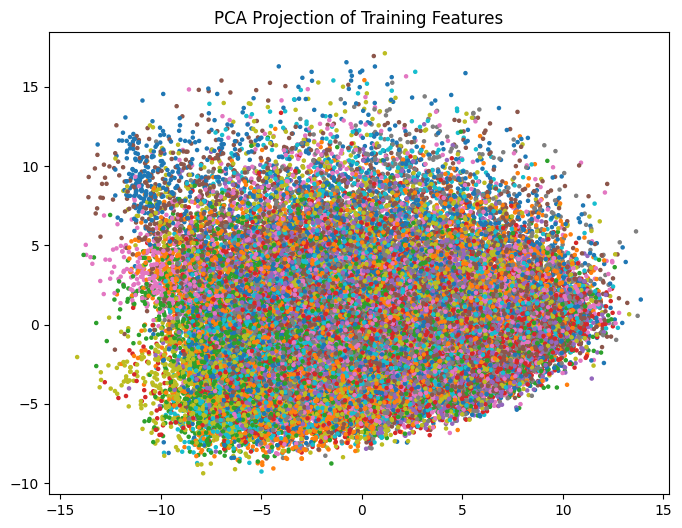

In [20]:
PCA_plot(X_train,"PCA Projection of Training Features")

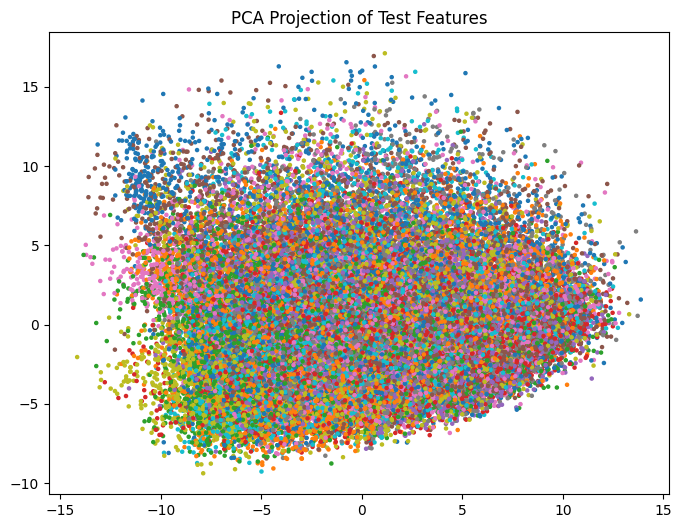

In [21]:
PCA_plot(X_train,"PCA Projection of Test Features")

## 3. Hyperparameter tuning on feature-level classifier

In [22]:
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
    "clf__max_iter": [500]
}

pipe = Pipeline([ ("scaler", StandardScaler()), ("clf", LogisticRegression()) ])
#log_reg = LogisticRegression()
grid = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_clf = grid.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'clf__C': 0.01, 'clf__max_iter': 500, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


##  4. Hyperparameter Tuning

In [ ]:
# ---------------------------------------------------------
# MODEL (ResNet18 adapted for CIFAR‑100)
# ---------------------------------------------------------
def build_model():
    model = resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, 100)   # CIFAR‑100 output
    return model.to(device)

# ---------------------------------------------------------
# TRAINING LOOP
# ---------------------------------------------------------
def train(model, loader, optimizer):
    model.train()
    total = 0
    correct = 0
    loss_sum = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

In [23]:
# ---------------------------------------------------------
# HYPERPARAMETER TUNING
# ---------------------------------------------------------
search_space = {
    "lr": [1e-3, 3e-4],
    "batch": [64, 128],
    "opt": ["adam", "sgd"]
}

best_acc = 0
best_cfg = None
best_model = None

for lr in search_space["lr"]:
    for batch in search_space["batch"]:
        for opt_name in search_space["opt"]:

            print(f"\nTesting config: lr={lr}, batch={batch}, opt={opt_name}")

            train_loader = DataLoader(train_set, batch_size=batch, shuffle=True)
            test_loader  = DataLoader(test_set, batch_size=batch, shuffle=False)

            model = build_model()

            if opt_name == "adam":
                optimizer = optim.Adam(model.parameters(), lr=lr)
            else:
                optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

            for epoch in range(3):  # small number for tuning
                train_loss, train_acc = train(model, train_loader, optimizer)
                print(f"Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.4f}")

            acc = evaluate(model, test_loader)
            print("Test accuracy:", acc)

            if acc > best_acc:
                best_acc = acc
                best_cfg = (lr, batch, opt_name)
                best_model = model

print("\nBest config:", best_cfg)
print("Best accuracy:", best_acc)


Testing config: lr=0.001, batch=64, opt=adam
Epoch 1: loss=3.4841, acc=0.1657
Epoch 2: loss=2.4868, acc=0.3452
Epoch 3: loss=1.9418, acc=0.4637
Test accuracy: 0.4656

Testing config: lr=0.001, batch=64, opt=sgd
Epoch 1: loss=4.1658, acc=0.0767
Epoch 2: loss=3.6081, acc=0.1510
Epoch 3: loss=3.2946, acc=0.2063
Test accuracy: 0.2316

Testing config: lr=0.001, batch=128, opt=adam
Epoch 1: loss=3.3463, acc=0.1893
Epoch 2: loss=2.3492, acc=0.3740
Epoch 3: loss=1.8440, acc=0.4854
Test accuracy: 0.4325

Testing config: lr=0.001, batch=128, opt=sgd
Epoch 1: loss=4.3573, acc=0.0543
Epoch 2: loss=3.9400, acc=0.1133
Epoch 3: loss=3.6490, acc=0.1516
Test accuracy: 0.1608

Testing config: lr=0.0003, batch=64, opt=adam
Epoch 1: loss=3.3239, acc=0.1986
Epoch 2: loss=2.3438, acc=0.3831
Epoch 3: loss=1.8225, acc=0.4991
Test accuracy: 0.4665

Testing config: lr=0.0003, batch=64, opt=sgd
Epoch 1: loss=4.4387, acc=0.0408
Epoch 2: loss=4.1283, acc=0.0861
Epoch 3: loss=3.9018, acc=0.1169
Test accuracy: 0.12

## 5. Feature Analysis — GRAD‑CAM

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


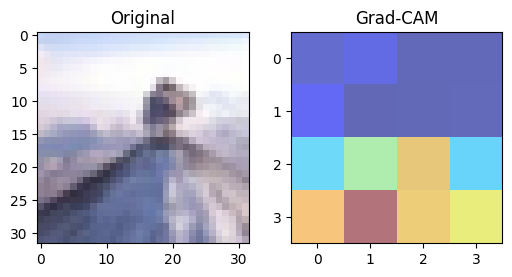

In [24]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.target_layer = target_layer

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, x, class_idx=None):
        self.model.zero_grad()
        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(1).item()

        loss = logits[:, class_idx]
        loss.backward()

        grads = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (grads * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam)
        cam = cam / cam.max()
        return cam.detach().cpu().numpy()

# pick a test image
img, label = test_set[0]
x = img.unsqueeze(0).to(device)

cam = GradCAM(best_model, best_model.layer4[-1])
heatmap = cam.generate(x)

# visualize
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow((img.permute(1,2,0)*0.5+0.5).numpy())

plt.subplot(1,2,2)
plt.title("Grad‑CAM")
plt.imshow((img.permute(1,2,0)*0.5+0.5).numpy())
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.show()